# Sentiment Analysis, with VNese dataset

Modern Approaches for NLP, Semester 252. 
<br>
<if my model's metrics are good enough, I would put this into my CV :))>

## Imports

In [1]:
!rm -rf ~/.cache/huggingface/hub/*

In [2]:
!pip install pyvi gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 86.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 66.6 MB/s eta 0:00:00


In [3]:

import re
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import gensim
from gensim.models.keyedvectors import KeyedVectors
from pyvi import ViTokenizer
from string import digits
from collections import Counter
from sklearn.metrics import accuracy_score
import unicodedata
%matplotlib inline

from datasets import Dataset
from transformers import AutoTokenizer

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
# Kiểm tra thiết bị (Sử dụng GPU nếu có)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


## EDA

### Data Retrievement

- Note: You will probably see another csv file named: vlsp_sentiment_train_augmented.csv. I won't use it in the assigned models, and I will talk about it later on.

In [4]:
train_df = pd.read_csv('/kaggle/input/datasets/anhphmduy/vlsp-sentiment-dataset/vlsp_sentiment_train.csv', sep='\t')
test_df = pd.read_csv('/kaggle/input/datasets/anhphmduy/vlsp-sentiment-dataset/vlsp_sentiment_test.csv', sep='\t')
# Xem 5 dòng đầu tiên của dữ liệu
print(train_df.head())
print(test_df.head())

   Class                                               Data
0     -1  Mình đã dùng anywhere thế hệ đầu, quả là đầy t...
1     -1  Quan tâm nhất là độ trễ có cao không, dùng thi...
2     -1  dag xài con cùi bắp 98k....pin trâu, mỗi tội đ...
3     -1  logitech chắc hàng phải tiền triệu trở lên dùn...
4     -1  Đang xài con m175 cùi mía , nhà xài nhiều chuộ...
   Class                                               Data
0     -1  Nói thiệt là mình thì thì chuột nào mình cũng ...
1     -1  Đang dùng mx1. Cũng ngon nhưng chưa đầy năm mà...
2     -1  Chưa thấy đc điểm thuyết phục để mua, nhất là ...
3     -1  Những phần xem báo tra cứu bản đồ, dịch vụ.. d...
4     -1  ĐÚNG LÀ MUA Ở VIỆT NAM KHÔNG ỨNG DỤNG ĐƯỢC GÌ ...


### Check for imbalances

In [5]:
print("=== TRAIN SET ===")
print(train_df.shape)
print(train_df.dtypes)
print(train_df.head())

print("\n=== TEST SET ===")
print(test_df.shape)
print(test_df.head())

# Kiểm tra missing values
print("\nMissing values (train):")
print(train_df.isnull().sum())

print("\nMissing values (test):")
print(test_df.isnull().sum())

=== TRAIN SET ===
(5100, 2)
Class     int64
Data     object
dtype: object
   Class                                               Data
0     -1  Mình đã dùng anywhere thế hệ đầu, quả là đầy t...
1     -1  Quan tâm nhất là độ trễ có cao không, dùng thi...
2     -1  dag xài con cùi bắp 98k....pin trâu, mỗi tội đ...
3     -1  logitech chắc hàng phải tiền triệu trở lên dùn...
4     -1  Đang xài con m175 cùi mía , nhà xài nhiều chuộ...

=== TEST SET ===
(1050, 2)
   Class                                               Data
0     -1  Nói thiệt là mình thì thì chuột nào mình cũng ...
1     -1  Đang dùng mx1. Cũng ngon nhưng chưa đầy năm mà...
2     -1  Chưa thấy đc điểm thuyết phục để mua, nhất là ...
3     -1  Những phần xem báo tra cứu bản đồ, dịch vụ.. d...
4     -1  ĐÚNG LÀ MUA Ở VIỆT NAM KHÔNG ỨNG DỤNG ĐƯỢC GÌ ...

Missing values (train):
Class    0
Data     0
dtype: int64

Missing values (test):
Class    0
Data     0
dtype: int64


Kết quả: Data vô cùng cân bằng 

### Check for Label distribution

Class distribution (train):
Class
-1    1700
 1    1700
 0    1700
Name: count, dtype: int64
Class
-1    0.333333
 1    0.333333
 0    0.333333
Name: proportion, dtype: float64


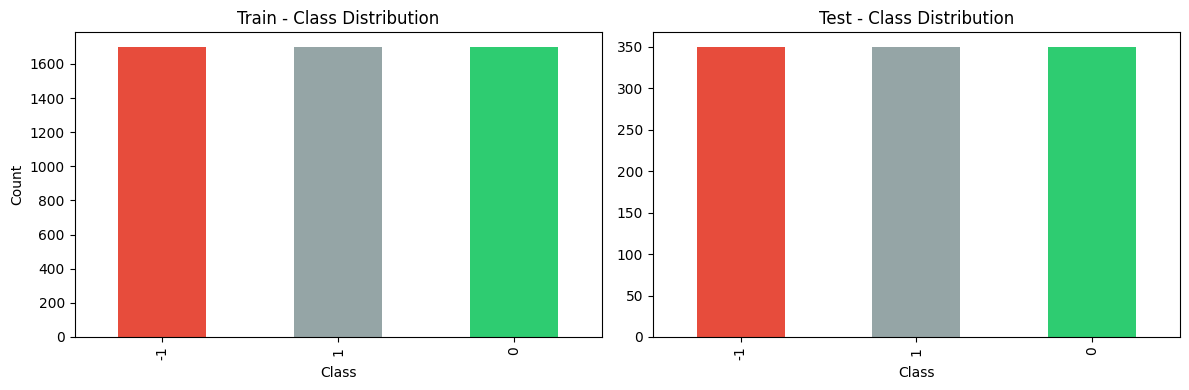

Class -1: 1700 samples (33.3%)
Class 1: 1700 samples (33.3%)
Class 0: 1700 samples (33.3%)


In [6]:
# Đếm số lượng từng class
print("Class distribution (train):")
print(train_df['Class'].value_counts())
print(train_df['Class'].value_counts(normalize=True))  # tỉ lệ %

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#95a5a6','#2ecc71'])
axes[0].set_title('Train - Class Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

test_df['Class'].value_counts().plot(kind='bar', ax=axes[1], color=['#e74c3c','#95a5a6','#2ecc71'])
axes[1].set_title('Test - Class Distribution')

plt.tight_layout()
plt.show()

# Kiểm tra imbalanced dataset
total = len(train_df)
for cls, cnt in train_df['Class'].value_counts().items():
    print(f"Class {cls}: {cnt} samples ({cnt/total*100:.1f}%)")

### Độ dài của các text

=== Text Length Statistics (Train) ===
        char_length   word_count
count   5100.000000  5100.000000
mean     129.749020    29.353922
std      309.700932    68.305252
min        2.000000     1.000000
25%       45.000000    10.000000
50%       81.000000    19.000000
75%      146.000000    33.000000
max    13164.000000  2885.000000


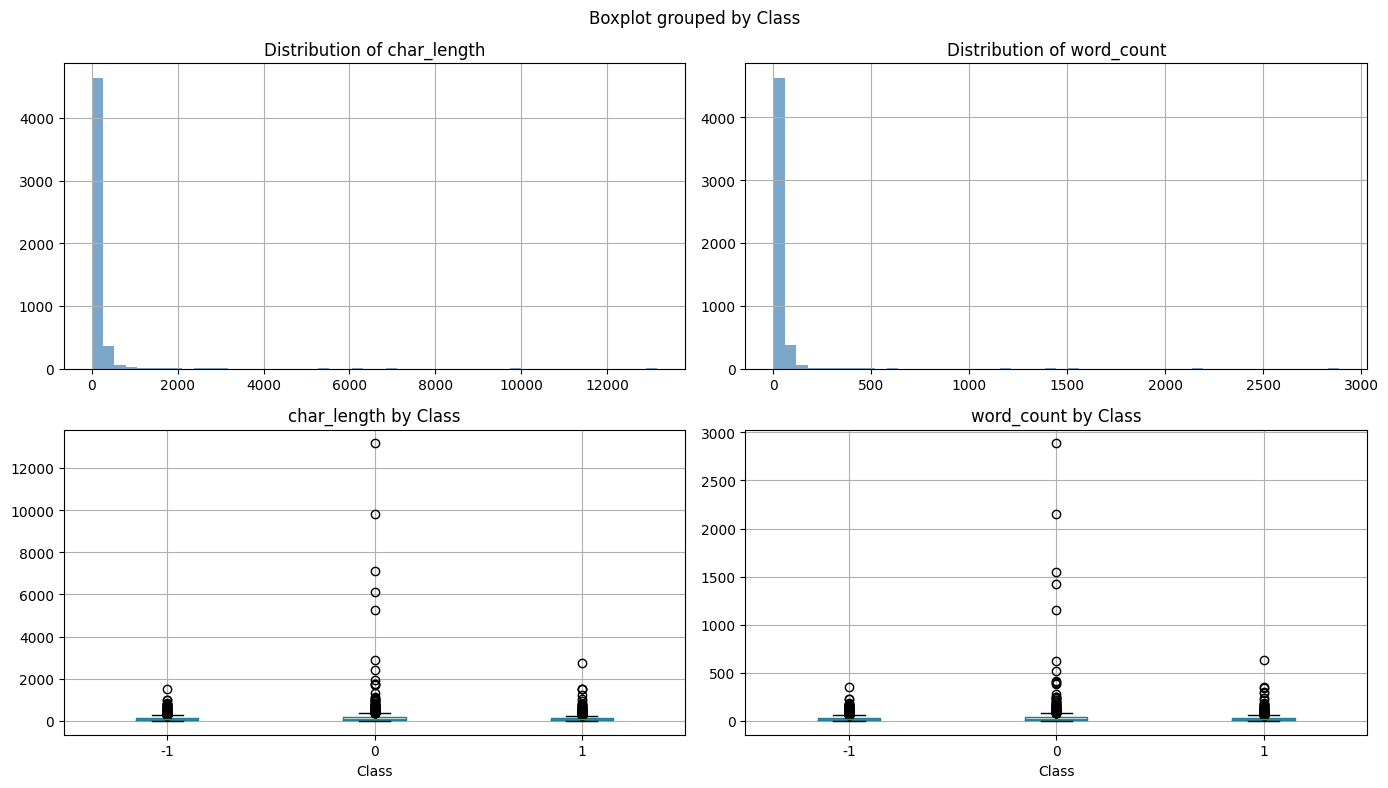


Rất ngắn (< 10 ký tự):
['Ế chắc' 'xấu nhỉ' 'Xấu quá!' 'K MUA' 'Cùi lắm' 'cho k lấy' 'Hơi đắt'
 'Chậm???' 'xấu tệ' 'Qua xấu' 'Quá xấu' 'Nhọ' 'Gét ss' 'Cùi lắm'
 'Xấu thật' 'Quá xấu' 'Chán' 'điên rồ' 'vẫn lag' 'xấu' 'Xấu quá' 'Xấu'
 'Thấy gớm' 'Đắt nhỉ?' 'Đắt quá.' 'Thua 1100' 'Xau qua' 'ngon quá'
 'đẹp thế' 'hì ngon' 'very good' 'Ngon quá' 'Ngầu phết' 'Tuyệt..'
 'đẹp phết' 'đẹp' 'Đẹp mê ly' 'Quá khủng' 'Ngon' 'Đẹp à' 'Đẹp quá'
 'Đẹp mà' 'Đẹp' 'Good' 'Hay đấy' 'Dep' 'quá tuyệt' 'siêu mạnh' 'good'
 'Đẹp quá' 'Giá ngon' 'Quá tuyệt' 'Đẹp' 'Quá đẹp' 'Ngon day' 'Ngon.'
 'quá đẹp' 'Thèm quá' 'đẹp ghê' 'rất tốt' 'NGON' 'Đẹp nhẹ' 'Đẹp ghê'
 'cũng đc' 'ngon :D' 'Quá rẻ!' 'Đẹp' 'Mê quá !' 'Tuyệt vời' 'tuyệt...'
 'quá khủng' 'Rẻ ghê ^^' 'đẹp quá.' 'Đẹp' 'Rẻ thế' 'đẹp thật' 'đẹp quá'
 'đẹp quá' 'Quá đẹp.' 'Mê quá !' 'Pin khủng' 'Dep qua' 'Đẹp đó.'
 'Quá đẹp.' 'Đẹp' 'Ngon' 'Rat dep' 'Ngon quá' 'Đẹp quá' 'tuyet voi'
 'Quá tuyệt' 'Đẹp!' 'Thích' 'ok' 'Ngon.' 'cũng bt' 'Vãi giá' 'Mua lg g4']

Rất d

In [7]:
# Tính độ dài theo ký tự và từ
train_df['char_length'] = train_df['Data'].str.len()
train_df['word_count']  = train_df['Data'].str.split().str.len()

test_df['char_length'] = test_df['Data'].str.len()
test_df['word_count']  = test_df['Data'].str.split().str.len()

# Thống kê mô tả
print("=== Text Length Statistics (Train) ===")
print(train_df[['char_length', 'word_count']].describe())

# Visualize phân phối độ dài theo class
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, col in enumerate(['char_length', 'word_count']):
    # Histogram tổng
    train_df[col].hist(bins=50, ax=axes[0][i], color='steelblue', alpha=0.7)
    axes[0][i].set_title(f'Distribution of {col}')

    # Boxplot theo class
    train_df.boxplot(column=col, by='Class', ax=axes[1][i])
    axes[1][i].set_title(f'{col} by Class')

plt.tight_layout()
plt.show()

# Phát hiện outliers (văn bản quá ngắn hoặc quá dài)
print("\nRất ngắn (< 10 ký tự):")
print(train_df[train_df['char_length'] < 10]['Data'].values)

print("\nRất dài (> 500 ký tự):")
print(train_df[train_df['char_length'] > 500].shape[0], "samples")

### Phân tích từ vựng

In [8]:
from collections import Counter
import re

# Tokenize đơn giản (trước khi dùng underthesea)
all_words = ' '.join(train_df['Data']).lower().split()
word_freq = Counter(all_words)

print(f"Total tokens   : {len(all_words):,}")
print(f"Unique tokens  : {len(word_freq):,}")
print(f"\nTop 20 words:\n{word_freq.most_common(20)}")

# Top words theo từng class
for cls in sorted(train_df['Class'].unique()):
    texts = ' '.join(train_df[train_df['Class'] == cls]['Data']).lower().split()
    freq  = Counter(texts)
    print(f"\n--- Class {cls} — Top 15 words ---")
    print(freq.most_common(15))

Total tokens   : 149,705
Unique tokens  : 12,638

Top 20 words:
[('là', 2095), ('có', 2091), ('thì', 1857), ('không', 1523), ('mình', 1267), ('của', 1184), ('và', 1146), ('mà', 1125), ('dùng', 1078), ('mua', 1043), ('cái', 1038), ('cũng', 1018), ('này', 938), ('với', 900), ('cho', 869), ('con', 857), ('ko', 804), ('giá', 799), ('hơn', 791), ('như', 790)]

--- Class -1 — Top 15 words ---
[('thì', 631), ('là', 569), ('có', 552), ('không', 517), ('cái', 401), ('mà', 375), ('dùng', 310), ('mua', 307), ('mình', 302), ('của', 300), ('cũng', 299), ('và', 297), ('này', 286), ('ko', 277), ('giá', 271)]

--- Class 0 — Top 15 words ---
[('có', 1047), ('là', 975), ('thì', 831), ('không', 668), ('của', 547), ('mình', 532), ('mà', 486), ('và', 485), ('cũng', 477), ('mua', 477), ('bạn', 461), ('với', 438), ('cho', 426), ('dùng', 400), ('cái', 394)]

--- Class 1 — Top 15 words ---
[('là', 551), ('có', 492), ('mình', 433), ('thì', 395), ('dùng', 368), ('và', 364), ('quá', 339), ('không', 338), ('của', 

## Data preprocessing

Dễ thấy, các text này chứa rất nhiều lượng teen code, điều này sẽ ảnh hưởng tới encoder cho các phần sau. 

### Data cleaning

In [9]:
# Đọc file dữ liệu
# 1. Từ điển Teen code & Viết tắt (Có thể bổ sung thêm)
replace_dict = {
    r'\bko\b': 'không', r'\bk\b': 'không', r'\bkh\b': 'không', r'\bkhg\b': 'không', r'\bhok\b': 'không', r'\bhk\b': 'không',
    r'\bdc\b': 'được', r'\bđc\b': 'được', r'\bđk\b': 'được', r'\bđx\b': 'được',
    r'\bsp\b': 'sản phẩm', r'\bad\b': 'admin',
    r'\bdt\b': 'điện thoại', r'\bđt\b': 'điện thoại',
    r'\bmik\b': 'mình', r'\bmk\b': 'mình',
    r'\br\b': 'rồi', r'\bm\b': 'mày', r'\bt\b': 'tao',
    r'\bvs\b': 'với', r'\bwa\b': 'quá', r'\bqúa\b': 'quá',
    r'\bntn\b': 'như thế nào', r'\bns\b': 'nói', r'\bnt\b': 'nhắn tin',
    r'\bkm\b': 'khuyến mãi', r'\bnhg\b': 'nhưng',
    r'\bthik\b': 'thích', r'\bthick\b': 'thích',
    r'\btk\b': 'tài khoản',
    r'\bhnay\b': 'hôm nay', r'\bhn\b': 'hà nội', r'\bhcm\b': 'hồ chí minh', r'\bsg\b': 'sài gòn',
    r'\bbthg\b': 'bình thường', r'\bbt\b': 'bình thường', r'\bchuẫn\b': 'chuẩn',
    r'\bvl\b': 'vui lắm', r'\bvcl\b': 'vui quá'
}

# 2. Từ điển chuyển đổi Emoticon mang cảm xúc
emoticon_dict = {
    r':\)': ' cười ', r':\(': ' buồn ', r':d': ' cười ', r':v': ' cười ',
    r'=\)\)': ' cười ', r'=d': ' cười ', r'\^\^': ' vui ',
    r'@@': ' bối rối ', r't\.t': ' khóc ', r'-_-': ' chán ', r'~_~': ' chán '
}

def clean_vietnamese_text(text):
    if not isinstance(text, str):
        return text
    
    # Lowercase
    text = text.lower()
    text = unicodedata.normalize('NFC', text)
    # Dịch emoticons sang text trước khi xóa ký tự đặc biệt
    for k, v in emoticon_dict.items():
        text = re.sub(k, v, text)
        
    # Thay thế teencode
    for k, v in replace_dict.items():
        text = re.sub(k, v, text)
    
    # Xóa Emoji và ký tự lạ (giữ lại tiếng Việt, số, và dấu câu cơ bản)
    text = re.sub(r'[^\w\s,.\?!]', ' ', text)
    
    # Cắt khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Áp dụng hàm làm sạch
train_df['Data'] = train_df['Data'].apply(clean_vietnamese_text)
# Áp dụng hàm làm sạch
test_df['Data'] = test_df['Data'].apply(clean_vietnamese_text)

train_df.to_csv('vlsp_sentiment_train_cleaned.csv')
test_df.to_csv('vlsp_sentiment_test_cleaned.csv')

### Remove stopwords

In [10]:
# # pip install pyvi  (hoặc dùng danh sách thủ công)
# VIETNAMESE_STOPWORDS = {
#     'và', 'của', 'cho', 'là', 'có', 'được', 'trong', 'với',
#     'các', 'này', 'đó', 'hay', 'thì', 'mà', 'nhưng', 'nên',
#     'một', 'những', 'như', 'vì', 'để', 'khi', 'từ', 'về',
#     'đã', 'sẽ', 'đang', 'rất', 'cũng', 'không', 'hơn', 'tôi',
#     'mình', 'bạn', 'họ', 'chúng', 'ở', 'ra', 'vào', 'theo',
#     'trên', 'dưới', 'lên', 'xuống', 'lại', 'đi', 'đến', 'tới',
# }

# def remove_stopwords(text):
#     words = text.split()
#     return ' '.join([w for w in words if w not in VIETNAMESE_STOPWORDS])

# # Lưu ý: với Sentiment Analysis, một số stopwords như "không" rất quan trọng
# # → Nên có 2 version: có và không có stopwords, rồi so sánh kết quả mô hình
# train_df['Data'] = train_df['Data'].apply(remove_stopwords)
# test_df['Data']  = test_df['Data'].apply(remove_stopwords)

In [11]:
print(train_df.shape)
print(train_df.head())

print(test_df.shape)
print(test_df.head())

(5100, 4)
   Class                                               Data  char_length  \
0     -1  mình đã dùng anywhere thế hệ đầu, quả là đầy t...          116   
1     -1  quan tâm nhất là độ trễ có cao không, dùng thi...          252   
2     -1  dag xài con cùi bắp 98k....pin trâu, mỗi tội đ...           80   
3     -1  logitech chắc hàng phải tiền triệu trở lên dùn...          158   
4     -1  đang xài con m175 cùi mía , nhà xài nhiều chuộ...          288   

   word_count  
0          26  
1          57  
2          18  
3          33  
4          72  
(1050, 4)
   Class                                               Data  char_length  \
0     -1  nói thiệt là mình thì thì chuột nào mình cũng ...          288   
1     -1  đang dùng mx1. cũng ngon nhưng chưa đầy năm mà...          123   
2     -1  chưa thấy được điểm thuyết phục để mua, nhất l...           52   
3     -1  những phần xem báo tra cứu bản đồ, dịch vụ.. d...          103   
4     -1  đúng là mua ở việt nam không ứng dụng

In [12]:
# Cấu hình hằng số
EMBEDDING_DIM = 400
MAX_VOCAB_SIZE = 10000 
MAX_SEQUENCE_LENGTH = 300

word_index = {}
is_tokenizer_trained = False

def process_and_tokenize(reviews):
    """Loại bỏ chữ số và tách từ bằng PyVi"""
    word_reviews = []
    for review in reviews:
        # Xóa chữ số
        review_no_digits = ''.join([char for char in str(review) if char not in digits])
        # Tách từ PyVi
        tokenized = ViTokenizer.tokenize(review_no_digits.lower())
        word_reviews.append(tokenized.split())
    return word_reviews

def build_vocab(word_reviews):
    """Xây dựng từ điển dựa trên tần suất xuất hiện (Giống Keras Tokenizer)"""
    all_words = [word for review in word_reviews for word in review]
    word_counts = Counter(all_words)
    # Giữ lại các từ phổ biến nhất, dành index 0 cho padding
    vocab = {word: i+1 for i, (word, _) in enumerate(word_counts.most_common(MAX_VOCAB_SIZE - 1))}
    return vocab

def texts_to_sequences(word_reviews, vocab):
    """Chuyển đổi văn bản thành dãy số"""
    return [[vocab[word] for word in review if word in vocab] for review in word_reviews]

def pad_sequences(sequences, maxlen):
    """Cắt hoặc thêm 0 (pre-padding) để các chuỗi có độ dài bằng nhau"""
    padded = np.zeros((len(sequences), maxlen), dtype=int)
    for i, seq in enumerate(sequences):
        if len(seq) > maxlen:
            # Nếu câu quá dài, cắt lấy maxlen từ đầu (hoặc cuối tùy chiến lược)
            padded[i, :] = seq[:maxlen] 
        else:
            # Pre-padding: chèn dữ liệu vào cuối mảng, để số 0 nằm ở đầu
            padded[i, -len(seq):] = seq 
    return padded

def prepareData_PyTorch(data, is_train=True):
    global word_index, is_tokenizer_trained
    
    labels = data.iloc[:, 0].values
    reviews = data.iloc[:, 1].values
    
    # PyTorch CrossEntropyLoss dùng index (0, 1, 2) thay vì One-Hot
    # Label gốc: -1 (Tiêu cực), 0 (Trung lập), 1 (Tích cực) -> Chuyển thành: 0, 1, 2
    encoded_labels = np.array([label + 1 for label in labels])
    
    # Tiền xử lý văn bản
    word_reviews = process_and_tokenize(reviews)
    
    # Xây dựng từ điển nếu là tập Train
    if is_train and not is_tokenizer_trained:
        word_index = build_vocab(word_reviews)
        is_tokenizer_trained = True
        
    # Ánh xạ từ thành số và padding
    sequences = texts_to_sequences(word_reviews, word_index)
    padded_data = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH)
    
    # Chuyển sang PyTorch Tensors
    tensor_x = torch.tensor(padded_data, dtype=torch.long)
    tensor_y = torch.tensor(encoded_labels, dtype=torch.long)
    
    return tensor_x, tensor_y

# Tiền xử lý tập Train và Test
X_train, y_train = prepareData_PyTorch(train_df, is_train=True)
X_test, y_test = prepareData_PyTorch(test_df, is_train=False)

# Tạo DataLoader
batch_size = 256
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# Cắt 20% tập train làm validation
val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [13]:
print(X_train)
print(y_train)

tensor([[   0,    0,    0,  ..., 4327,    2,  433],
        [   0,    0,    0,  ...,  462, 4329,   58],
        [   0,    0,    0,  ...,  663,  118,   23],
        ...,
        [   0,    0,    0,  ..., 3057,  120,  360],
        [   0,    0,    0,  ...,  552,  120,  322],
        [   0,    0,    0,  ...,   27,  757,  757]])
tensor([0, 0, 0,  ..., 1, 1, 1])


### Load W2V

In [14]:
# Tải mô hình Word2Vec
print("Đang tải mô hình Word2Vec...")
word_vectors = KeyedVectors.load_word2vec_format('/kaggle/input/datasets/anhphmduy/vlsp-sentiment-dataset/vi-model-CBOW.bin', binary=True)

vocabulary_size = min(len(word_index) + 1, MAX_VOCAB_SIZE)
embedding_matrix = np.zeros((vocabulary_size, EMBEDDING_DIM))

for word, i in word_index.items():
    if i >= MAX_VOCAB_SIZE:
        continue
    try:
        embedding_matrix[i] = word_vectors[word]
    except KeyError:
        # Khởi tạo ngẫu nhiên nếu từ không có trong Word2Vec
        embedding_matrix[i] = np.random.normal(0, np.sqrt(0.25), EMBEDDING_DIM)

del word_vectors # Giải phóng bộ nhớ

# Chuyển sang tensor
embedding_tensor = torch.FloatTensor(embedding_matrix)
print(f"Kích thước Embedding: {embedding_matrix.shape}")

Đang tải mô hình Word2Vec...
Kích thước Embedding: (7888, 400)


## Thiết kế Model

### CNN

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TextCNN_Model(nn.Module):
    def __init__(self, pretrained_embeddings, num_classes=3, num_filters=100, filter_sizes=[3, 4, 5], drop_prob=0.5):
        super(TextCNN_Model, self).__init__()
        
        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        
        # Tạo danh sách các Conv1d layer cho từng kích thước kernel (tương đương 3-gram, 4-gram, 5-gram)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=EMBEDDING_DIM, 
                      out_channels=num_filters, 
                      kernel_size=fs) 
            for fs in filter_sizes
        ])
        
        self.dropout = nn.Dropout(drop_prob)
        # Đầu ra của Max Pooling sẽ có kích thước bằng tổng số filters
        self.fc = nn.Linear(len(filter_sizes) * num_filters, num_classes)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len)
        x = self.embedding(x) 
        # x shape: (batch_size, seq_len, embed_dim)
        
        # PyTorch Conv1d yêu cầu input có dạng: (batch_size, channels, seq_len)
        x = x.permute(0, 2, 1) 
        # x shape: (batch_size, embed_dim, seq_len)
        
        # Áp dụng Tích chập (Convolution) -> Hàm kích hoạt ReLU -> Max-over-time Pooling
        conved = [F.relu(conv(x)) for conv in self.convs]
        # conved[n] shape: (batch_size, num_filters, seq_len - filter_sizes[n] + 1)
        
        # Dùng hàm max_pool1d với kích thước bằng chính chiều dài chuỗi còn lại
        pooled = [F.max_pool1d(c, c.shape[2]).squeeze(2) for c in conved]
        # pooled[n] shape: (batch_size, num_filters)
        
        # Nối tất cả các đặc trưng lại với nhau
        cat = self.dropout(torch.cat(pooled, dim=1)) 
        # cat shape: (batch_size, num_filters * len(filter_sizes))
        
        return self.fc(cat)

### LSTM

In [16]:
class LSTM_Model(nn.Module):
    def __init__(self, pretrained_embeddings, num_classes=3, hidden_dim=64):
        super(LSTM_Model, self).__init__()
        # Khởi tạo embedding (có thể set freeze=True trong vài epoch đầu nếu muốn)
        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        
        # Thêm bidirectional=True để mô hình đọc từ 2 chiều
        self.lstm = nn.LSTM(EMBEDDING_DIM, hidden_dim, batch_first=True, bidirectional=True)
        
        # Do là Bi-LSTM nên đầu ra sẽ có kích thước gấp đôi (hidden_dim * 2)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len)
        x = self.embedding(x) 
        # x shape: (batch_size, seq_len, embed_dim)
        
        lstm_out, _ = self.lstm(x)
        # lstm_out shape: (batch_size, seq_len, hidden_dim * 2)
        
        # Dùng Global Average Pooling thay vì lấy trạng thái cuối cùng
        # Tính trung bình dọc theo chiều seq_len (dim=1)
        out = torch.mean(lstm_out, dim=1) 
        # out shape: (batch_size, hidden_dim * 2)
        
        out = self.fc(out)
        return out

### CNN + LSTM models

In [17]:
class CNN_LSTM_Model(nn.Module):
    def __init__(self, pretrained_embeddings, num_classes=3, num_filters=128, kernel_size=3, lstm_hidden=64, drop_prob=0.5):
        super(CNN_LSTM_Model, self).__init__()
        
        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        
        # Lớp CNN để trích xuất n-gram cục bộ
        self.conv = nn.Conv1d(in_channels=EMBEDDING_DIM, out_channels=num_filters, kernel_size=kernel_size)
        
        # Lớp Bi-LSTM đọc chuỗi đặc trưng (số features đầu vào lúc này là num_filters của CNN)
        self.lstm = nn.LSTM(input_size=num_filters, hidden_size=lstm_hidden, batch_first=True, bidirectional=True)
        
        self.dropout = nn.Dropout(drop_prob)
        # Đầu ra lstm_hidden * 2 do dùng Bidirectional
        self.fc = nn.Linear(lstm_hidden * 2, num_classes)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len)
        x = self.embedding(x) 
        x = x.permute(0, 2, 1) 
        # x shape: (batch_size, embed_dim, seq_len)
        
        # Chạy qua Conv1D và kích hoạt ReLU
        x = F.relu(self.conv(x)) 
        # x shape: (batch_size, num_filters, seq_len_new) 
        
        # Đưa về lại dạng (batch_size, seq_len_new, input_size) để cho vào LSTM
        x = x.permute(0, 2, 1)
        
        lstm_out, (hidden, cell) = self.lstm(x) 
        # lstm_out shape: (batch_size, seq_len_new, lstm_hidden * 2)
        
        # Lấy Global Average Pooling của LSTM tương tự như đã fix ở phiên bản trước
        out = torch.mean(lstm_out, dim=1) 
        # out shape: (batch_size, lstm_hidden * 2)
        
        out = self.dropout(out)
        return self.fc(out)

In [18]:
def train_model(model, train_loader, val_loader, epochs=15, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    # Thêm L2 Regularization thông qua weight_decay
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5) 
    
    best_val_loss = float('inf')
    patience_counter = 0
    patience = 4 # Early stopping patience
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        total_train = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        total_val = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        val_acc = val_correct / total_val
        
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} - Acc: {train_correct/total_train:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} - Acc: {val_acc:.4f}")
              
        # Early Stopping Logic
        if avg_val_loss < best_val_loss - 0.01:
            best_val_loss = avg_val_loss
            patience_counter = 0
            # Có thể lưu mô hình tốt nhất ở đây: torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Kích hoạt Early Stopping!")
                break

# Huấn luyện CNN
print("\n--- HUẤN LUYỆN TEXTCNN ---")
cnn_model = TextCNN_Model(embedding_tensor)
train_model(cnn_model, train_loader, val_loader, epochs=15, lr=0.001)


print("\n--- HUẤN LUYỆN LSTM ---")
lstm_model = LSTM_Model(embedding_tensor)
train_model(lstm_model, train_loader, val_loader, epochs=15)

# Huấn luyện CNN + LSTM
print("\n--- HUẤN LUYỆN CNN + LSTM ---")
cnn_lstm_model = CNN_LSTM_Model(embedding_tensor)
train_model(cnn_lstm_model, train_loader, val_loader, epochs=15, lr=0.001)


# Khởi tạo và Huấn luyện LSTM



--- HUẤN LUYỆN TEXTCNN ---
Epoch 1/15 | Train Loss: 1.2584 - Acc: 0.4363 | Val Loss: 0.8836 - Acc: 0.6029
Epoch 2/15 | Train Loss: 0.7892 - Acc: 0.6544 | Val Loss: 0.8120 - Acc: 0.6608
Epoch 3/15 | Train Loss: 0.6434 - Acc: 0.7380 | Val Loss: 0.8040 - Acc: 0.6696
Epoch 4/15 | Train Loss: 0.5110 - Acc: 0.8049 | Val Loss: 0.7855 - Acc: 0.6716
Epoch 5/15 | Train Loss: 0.4155 - Acc: 0.8576 | Val Loss: 0.7829 - Acc: 0.6775
Epoch 6/15 | Train Loss: 0.3299 - Acc: 0.8907 | Val Loss: 0.8061 - Acc: 0.6676
Epoch 7/15 | Train Loss: 0.2670 - Acc: 0.9221 | Val Loss: 0.8368 - Acc: 0.6539
Epoch 8/15 | Train Loss: 0.2123 - Acc: 0.9385 | Val Loss: 0.8560 - Acc: 0.6451
Kích hoạt Early Stopping!

--- HUẤN LUYỆN LSTM ---
Epoch 1/15 | Train Loss: 1.0919 - Acc: 0.3777 | Val Loss: 1.0855 - Acc: 0.4500
Epoch 2/15 | Train Loss: 1.0829 - Acc: 0.4304 | Val Loss: 1.0770 - Acc: 0.4441
Epoch 3/15 | Train Loss: 1.0698 - Acc: 0.4488 | Val Loss: 1.0624 - Acc: 0.4775
Epoch 4/15 | Train Loss: 1.0582 - Acc: 0.5127 | Val 

## Eval

In [19]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    acc = accuracy_score(all_labels, all_preds)
    return acc

# Đánh giá CNN
cnn_acc = evaluate_model(cnn_model, test_loader)
print(f"Độ chính xác mô hình TextCNN: {cnn_acc * 100:.2f}%")


lstm_acc = evaluate_model(lstm_model, test_loader)
print(f"Độ chính xác mô hình LSTM: {lstm_acc * 100:.2f}%")

# Đánh giá CNN + LSTM
cnn_lstm_acc = evaluate_model(cnn_lstm_model, test_loader)
print(f"Độ chính xác mô hình CNN+LSTM: {cnn_lstm_acc * 100:.2f}%")
# Khởi tạo và Huấn luyện LSTM

Độ chính xác mô hình TextCNN: 68.57%
Độ chính xác mô hình LSTM: 62.86%
Độ chính xác mô hình CNN+LSTM: 65.05%


## Self-Proposed model: BERT
Dễ thấy, các model trên tuy đã qua xử lý tương đối kỹ, nhưng hiệu năng đạt được thực tế lại không quá cao. <br>
Em quyết định thử nghiệm với 1 model tiên tiến hơn: BERT.

### Gọi lại Dataset mới
- Dựa vào bản clean đã được thực hiện ở trên, Em có thực hiện augmentation cho bộ dữ liệu train_cleaned. Việc augment thực hiện bằng cách cho chạy qua 1 lần dịch từ tiếng Việt qua tiếng Anh, và từ tiếng Anh dịch ngược về tiếng Việt. Việc hiện thực diễn ra trên 1 notebook khác(vì sợ tốn tài nguyên GPUs :))). Kết quả là vlsp_sentiment_train_augmented_v2.csv

In [20]:
bert_train_df = pd.read_csv('/kaggle/input/datasets/anhphmduy/vlsp-sentiment-dataset/vlsp_sentiment_train_augmented_v2.csv', sep = '\t')
bert_test_df = pd.read_csv('/kaggle/input/datasets/anhphmduy/vlsp-sentiment-dataset/vlsp_sentiment_test_cleaned.csv')
bert_test_df = bert_test_df[['Class', 'Data']]

print("=== TRAIN SET ===")
print(bert_train_df.shape)
print(bert_train_df.head())

print("\n=== TEST SET ===")
print(bert_test_df.shape)
print(bert_test_df.head())

=== TRAIN SET ===
(10149, 2)
   Class                                               Data
0      1                                      trời ơi rẻ dữ
1      0  ram lên nhiều làm gì, màn hình độ phân giải th...
2      1  giờ còn máy mới đâu mà pin trâu , mua qsd được...
3      1  Bạn có thể mua romoss polimos 10 dung lượng 10...
4     -1                                  ngày càng tào lao

=== TEST SET ===
(1050, 2)
   Class                                               Data
0     -1  nói thiệt là mình thì thì chuột nào mình cũng ...
1     -1  đang dùng mx1. cũng ngon nhưng chưa đầy năm mà...
2     -1  chưa thấy được điểm thuyết phục để mua, nhất l...
3     -1  những phần xem báo tra cứu bản đồ, dịch vụ.. d...
4     -1  đúng là mua ở việt nam không ứng dụng được gì ...


In [21]:
from huggingface_hub import snapshot_download
# --- 2. Ánh xạ nhãn (-1, 0, 1) -> (0, 1, 2) ---
label_mapping = {-1: 0, 0: 1, 1: 2}
bert_train_df['Class'] = bert_train_df['Class'].map(label_mapping)
bert_test_df['Class'] = bert_test_df['Class'].map(label_mapping)


# --- 4. Chuyển sang định dạng HuggingFace Dataset ---
train_dataset = Dataset.from_pandas(bert_train_df)
test_dataset = Dataset.from_pandas(bert_test_df)

# --- 5. Tokenize dữ liệu ---
model_name = "vinai/phobert-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
local_dir = snapshot_download(
    repo_id=model_name,
    local_dir="/kaggle/working/phobert-large-local",
    local_dir_use_symlinks=False,
    resume_download=True
)
def tokenize_function(examples):
    return tokenizer(examples["Data"], padding="max_length", truncation=True, max_length=256)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# Chuẩn hóa tên cột cho model
tokenized_train = tokenized_train.remove_columns(["Data"])
tokenized_train = tokenized_train.rename_column("Class", "labels")

tokenized_test = tokenized_test.remove_columns(["Data"])
tokenized_test = tokenized_test.rename_column("Class", "labels")

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:186: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Map:   0%|          | 0/10149 [00:00<?, ? examples/s]

Map:   0%|          | 0/1050 [00:00<?, ? examples/s]

In [22]:
from datasets import ClassLabel

# 1. Ép kiểu cột 'labels' sang ClassLabel (vì bạn có 3 nhãn: 0, 1, 2)
tokenized_train = tokenized_train.cast_column(
    "labels", 
    ClassLabel(num_classes=3, names=["0", "1", "2"])
)

# 2. Bây giờ bạn có thể chia tập dữ liệu với stratify bình thường
split = tokenized_train.train_test_split(test_size=0.1, seed=42, stratify_by_column="labels")
train_split = split["train"]
val_split   = split["test"]

Casting the dataset:   0%|          | 0/10149 [00:00<?, ? examples/s]

In [23]:
import numpy as np
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    TrainerCallback
)
from sklearn.metrics import accuracy_score, f1_score


# Load model local
model = AutoModelForSequenceClassification.from_pretrained(
    "/kaggle/working/phobert-large-local",
    num_labels=3
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro"),
    }

training_args = TrainingArguments(
    output_dir="./phobert_large_sentiment",
    learning_rate=1.5e-5,

    # Với PhoBERT-large trên T4 nên giảm batch
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=4,

    num_train_epochs=6,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",

    eval_strategy="epoch",
    save_strategy="epoch",              # vẫn save theo epoch (nhưng callback sẽ chặn epoch < 3)
    load_best_model_at_end=True,
    save_total_limit=2,   
    metric_for_best_model="f1",         # save/best theo f1
    greater_is_better=True,
# chỉ giữ 1 checkpoint (cũ sẽ bị xóa)
    fp16=True,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_split,
    eval_dataset=val_split,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2)
    ]
)

trainer.train()
trainer.evaluate(tokenized_test)

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: /kaggle/working/phobert-large-local
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params 

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,1.454876,0.675862,0.678288
2,No log,1.232339,0.738916,0.741340
3,No log,1.139085,0.769458,0.769215
4,5.361363,1.173206,0.780296,0.780005
5,5.361363,1.195606,0.788177,0.786005
6,5.361363,1.193713,0.794089,0.792694


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

{'eval_loss': 1.432763934135437,
 'eval_accuracy': 0.74,
 'eval_f1': 0.7382032515274087,
 'eval_runtime': 30.2418,
 'eval_samples_per_second': 34.72,
 'eval_steps_per_second': 1.091,
 'epoch': 6.0}

In [24]:
from sklearn.metrics import classification_report

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average='macro'),  # macro quan trọng hơn
        "f1_weighted": f1_score(labels, predictions, average='weighted'),
    }

# Sau khi train xong, in báo cáo chi tiết
results = trainer.predict(tokenized_test)
preds = np.argmax(results.predictions, axis=-1)
print(classification_report(
    results.label_ids, preds,
    target_names=['Negative', 'Neutral', 'Positive']
))

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


              precision    recall  f1-score   support

    Negative       0.75      0.77      0.76       350
     Neutral       0.69      0.63      0.66       350
    Positive       0.78      0.82      0.80       350

    accuracy                           0.74      1050
   macro avg       0.74      0.74      0.74      1050
weighted avg       0.74      0.74      0.74      1050



In [25]:
# Cell 1: Utility functions để evaluate thống nhất cho cả PyTorch models và HF Trainer

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluate_torch_model_full(model, data_loader, device):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.numpy().tolist())
    
    metrics = {
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision_macro": precision_score(all_labels, all_preds, average="macro", zero_division=0),
        "recall_macro": recall_score(all_labels, all_preds, average="macro", zero_division=0),
        "f1_macro": f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "precision_weighted": precision_score(all_labels, all_preds, average="weighted", zero_division=0),
        "recall_weighted": recall_score(all_labels, all_preds, average="weighted", zero_division=0),
        "f1_weighted": f1_score(all_labels, all_preds, average="weighted", zero_division=0),
    }
    return metrics

def evaluate_hf_trainer_full(trainer, hf_dataset):
    pred_output = trainer.predict(hf_dataset)
    y_true = pred_output.label_ids
    y_pred = np.argmax(pred_output.predictions, axis=-1)
    
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    return metrics

In [26]:
# Cell 2: Thu thập metrics của 4 models

results = {}

# 3 mô hình PyTorch
results["TextCNN"] = evaluate_torch_model_full(cnn_model, test_loader, device)
results["BiLSTM"] = evaluate_torch_model_full(lstm_model, test_loader, device)
results["CNN+BiLSTM"] = evaluate_torch_model_full(cnn_lstm_model, test_loader, device)

# PhoBERT (HF Trainer)
results["PhoBERT-large"] = evaluate_hf_trainer_full(trainer, tokenized_test)

results

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'TextCNN': {'accuracy': 0.6857142857142857,
  'precision_macro': 0.6936415412927275,
  'recall_macro': 0.6857142857142856,
  'f1_macro': 0.6843950042741437,
  'precision_weighted': 0.6936415412927274,
  'recall_weighted': 0.6857142857142857,
  'f1_weighted': 0.6843950042741438},
 'BiLSTM': {'accuracy': 0.6285714285714286,
  'precision_macro': 0.6277512436334014,
  'recall_macro': 0.6285714285714286,
  'f1_macro': 0.6255893173528843,
  'precision_weighted': 0.6277512436334014,
  'recall_weighted': 0.6285714285714286,
  'f1_weighted': 0.6255893173528841},
 'CNN+BiLSTM': {'accuracy': 0.6504761904761904,
  'precision_macro': 0.6688493426508618,
  'recall_macro': 0.6504761904761905,
  'f1_macro': 0.6468331445895376,
  'precision_weighted': 0.6688493426508618,
  'recall_weighted': 0.6504761904761904,
  'f1_weighted': 0.6468331445895376},
 'PhoBERT-large': {'accuracy': 0.74,
  'precision_macro': 0.7377642325246218,
  'recall_macro': 0.7399999999999999,
  'f1_macro': 0.7382032515274087,
  'pr

In [27]:
# Cell 3: Tạo bảng so sánh đẹp + phần trăm

metrics_df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})

# Sắp xếp theo F1 macro (quan trọng cho multi-class cân bằng)
metrics_df = metrics_df.sort_values(by="f1_macro", ascending=False).reset_index(drop=True)

# Hiển thị bảng gốc (0-1)
display(metrics_df)

# Hiển thị bảng %
metrics_percent = metrics_df.copy()
for c in metrics_percent.columns:
    if c != "Model":
        metrics_percent[c] = (metrics_percent[c] * 100).round(2)

display(metrics_percent)

,Model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,PhoBERT-large,0.740000,0.737764,0.740000,0.738203,0.737764,0.740000,0.738203
1,TextCNN,0.685714,0.693642,0.685714,0.684395,0.693642,0.685714,0.684395
2,CNN+BiLSTM,0.650476,0.668849,0.650476,0.646833,0.668849,0.650476,0.646833
3,BiLSTM,0.628571,0.627751,0.628571,0.625589,0.627751,0.628571,0.625589


,Model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,PhoBERT-large,74.00,73.78,74.00,73.82,73.78,74.00,73.82
1,TextCNN,68.57,69.36,68.57,68.44,69.36,68.57,68.44
2,CNN+BiLSTM,65.05,66.88,65.05,64.68,66.88,65.05,64.68
3,BiLSTM,62.86,62.78,62.86,62.56,62.78,62.86,62.56


In [28]:
# Cell 4: In model tốt nhất theo từng metric chính

best_acc_model = metrics_df.loc[metrics_df["accuracy"].idxmax(), "Model"]
best_f1_macro_model = metrics_df.loc[metrics_df["f1_macro"].idxmax(), "Model"]
best_f1_weighted_model = metrics_df.loc[metrics_df["f1_weighted"].idxmax(), "Model"]

print(f"Best Accuracy      : {best_acc_model}")
print(f"Best F1 Macro      : {best_f1_macro_model}")
print(f"Best F1 Weighted   : {best_f1_weighted_model}")

Best Accuracy      : PhoBERT-large
Best F1 Macro      : PhoBERT-large
Best F1 Weighted   : PhoBERT-large


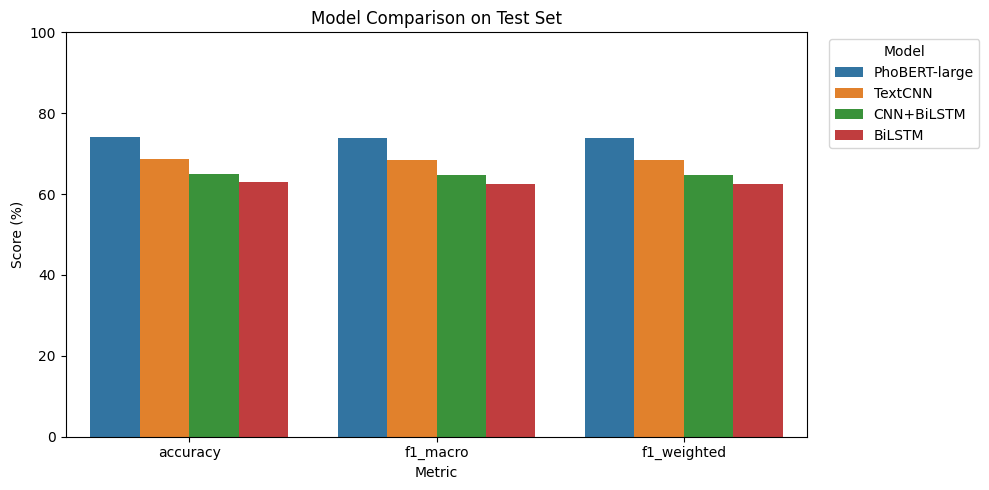

In [29]:
# Cell 5 (optional): Vẽ chart so sánh trực quan

import matplotlib.pyplot as plt
import seaborn as sns

plot_df = metrics_percent.melt(
    id_vars="Model",
    value_vars=["accuracy", "f1_macro", "f1_weighted"],
    var_name="Metric",
    value_name="Score (%)"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="Metric", y="Score (%)", hue="Model")
plt.title("Model Comparison on Test Set")
plt.ylim(0, 100)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()